 # Convolusional Neural Network Model

 This file contains the CNN implemented for classifying the different tumor types within the dataset by leveraging a CNN.

 ## Imports and Helper Functions

In [10]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


 ## Model Configuration

In [11]:
# Model Hyperparameters
DATA_ROOT = "."  # parent folder containing Training/ and Testing/
EPOCHS = 50  # Number of epochs to train the model
BATCH_SIZE = 64  # Batch size for training
LR = 1e-2  # Learning rate
VAL_FRACTION = 0.3  # Fraction of the dataset to use for validation
SEED = 42  # Random seed for reproducibility
DROPOUT = 0.5  # Dropout rate
IMG_SIZE = 64  # square H=W, aligning to the baseline notebook
CLASSES: List[str] = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASSES)


 ## Random Seed

In [12]:
# Set the seed for the random number generator
def set_seed(seed: int) -> None:
    # Set the seed for the random number generator
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


 ## Image Loader Helper

In [13]:
def load_image_tensors(
    base_path: str,  # path to the parent folder containing the Training/ and Testing/ folders
    classes: List[str],  # list of classes to load
    img_size: Tuple[int, int] = (64, 64),  # square H=W, aligning to the baseline notebook
) -> Tuple[np.ndarray, np.ndarray]:
    """Return X (N, 1, H, W) float32 in [0,1] and y int64 labels 0..K-1."""
    h, w = img_size
    # initialize empty lists to store the images and labels
    xs: List[np.ndarray] = []
    ys: List[int] = []

    # iterate over the classes
    for label_idx, cls in enumerate(classes):
        # get the path to the folder containing the images for the current class
        folder = os.path.join(base_path, cls)
        if not os.path.isdir(folder):
            print(f"Warning: folder not found -> {folder}")
            continue

        # load all images in the folder
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            img_path = os.path.join(folder, fname)
            try:
                # open the image and convert to grayscale
                img = Image.open(img_path).convert("L")
                # resize the image to the desired size
                img = img.resize((w, h))
                # convert the image to a numpy array
                arr = np.asarray(img, dtype=np.float32) / 255.0
                if arr.shape != (h, w):
                    print(f"Skipping malformed image: {img_path}")
                    continue
                # add the image to the list of images
                xs.append(arr[np.newaxis, ...])
                # add the label to the list of labels
                ys.append(label_idx)
            except OSError as e:
                print(f"Skipping {img_path}: {e}")

    # sanity check
    if not xs:
        raise RuntimeError(f"No images loaded from {base_path}")

    # force a true numeric 2D matrix
    X = np.stack(xs, axis=0).astype(np.float32)
    y = np.asarray(ys, dtype=np.int64)

    return X, y



 ## Model

In [14]:
# define the model
class BrainTumorCNN(nn.Module):
    """CNN for grayscale MRI tiles (e.g. 64x64)."""

    # initialize the model
    def __init__(self, num_classes: int = NUM_CLASSES, dropout: float = 0.5) -> None:
        # call the parent class constructor
        super().__init__()
        
        # define the first convolutional layer
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # define the second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # define the third convolutional layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # define the fourth convolutional layer
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # define the max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # define the adaptive average pooling layer
        self.adaptive_pool = nn.AdaptiveAvgPool2d(1)
        
        # define the first fully connected layer
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(dropout)
        
        # define the second fully connected layer
        self.fc2 = nn.Linear(128, num_classes)

    # forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # apply the convolutional layers
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)



 ## Training and Evaluation Loops

In [15]:
# Training Loop
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    # set the model to training mode
    model.train()
    # initialize the total loss and the number of batches
    total_loss = 0.0
    n_batches = 0

    # iterate over the batches
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        # zero the gradients
        optimizer.zero_grad()
        # forward pass
        logits = model(batch_x)
        # compute the loss
        loss = criterion(logits, batch_y)
        # backward pass
        loss.backward()
        # update the weights
        optimizer.step()
        # update the total loss
        total_loss += loss.item()
        n_batches += 1
    # return the average loss
    return total_loss / max(n_batches, 1)


# Evaluation Loop
@torch.no_grad()
# evaluate the model
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    
    # set the model to evaluation mode
    model.eval()
    # initialize the total loss and the number of batches
    total_loss = 0.0
    n_batches = 0
    # initialize the lists to store the predictions, probabilities, and labels
    all_preds: List[int] = []
    all_probs: List[np.ndarray] = []
    all_y: List[int] = []

    # iterate over the batches
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        total_loss += loss.item()
        n_batches += 1
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.extend(preds.tolist())
        all_y.extend(batch_y.cpu().numpy().tolist())

    # return the average loss, the true labels, the predicted labels, and the probabilities
    avg_loss = total_loss / max(n_batches, 1)
    y_true = np.asarray(all_y, dtype=np.int64)
    y_pred = np.asarray(all_preds, dtype=np.int64)
    y_prob = np.concatenate(all_probs, axis=0) if all_probs else np.empty((0, NUM_CLASSES))
    return avg_loss, y_true, y_pred, y_prob


# Training / Evaluation Loops
def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    # define the loss function
    criterion = nn.CrossEntropyLoss()
    # define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # initialize the best state and the best F1 score
    best_state = None
    best_f1 = -1.0

    # per-epoch metrics for learning curves (loss / acc / macro F1 on train & val)
    history: Dict[str, List[float]] = {
        "train_losses": [],
        "val_losses": [],
        "train_accuracies": [],
        "val_accuracies": [],
        "train_macro_f1s": [],
        "val_macro_f1s": [],
    }

    # iterate over the epochs
    for epoch in range(1, epochs + 1):
        # train the model (one pass over training batches)
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        # evaluate on training set (for accuracy / F1 curves; model in eval mode inside evaluate)
        _, y_tr, y_tr_pred, _ = evaluate(model, train_loader, criterion, device)
        # evaluate on validation set
        val_loss, y_val, y_val_pred, _ = evaluate(model, val_loader, criterion, device)

        train_acc = accuracy_score(y_tr, y_tr_pred)
        val_acc = accuracy_score(y_val, y_val_pred)
        train_f1 = f1_score(y_tr, y_tr_pred, average="macro", zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

        history["train_losses"].append(train_loss)
        history["val_losses"].append(val_loss)
        history["train_accuracies"].append(train_acc)
        history["val_accuracies"].append(val_acc)
        history["train_macro_f1s"].append(train_f1)
        history["val_macro_f1s"].append(val_f1)

        # print the results
        print(
            f"Epoch {epoch}/{epochs}  "
            f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
            f"val_macro_f1={val_f1:.4f}"
        )

        # update the best state and the best F1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # if the best state is not None, load the best state
    if best_state is not None:
        model.load_state_dict(best_state)
    # return the model and training history for plotting
    return model, history


def report_test_metrics(
    model: nn.Module,
    X_test: np.ndarray,
    y_test: np.ndarray,
    batch_size: int,
    device: torch.device,
) -> np.ndarray:
    test_ds = TensorDataset(
        torch.from_numpy(X_test),
        torch.from_numpy(y_test),
    )

    # create the test loader
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    # define the loss function
    criterion = nn.CrossEntropyLoss()
    # evaluate the model
    _, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

    # compute the accuracy and the macro F1 score
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # print the results
    print("\n--- Test set (held-out) ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASSES,
            zero_division=0,
        )
    )

    # print the confusion matrix
    cm_test = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm_test)

    # compute the ROC-AUC score
    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
        )
        #one vs rest roc curve means comparing one class against the rest of the classes
        #so for each class, the model is trained to distinguish it from the rest of the classes
        #and then the roc curve is plotted for each class
        print(f"\nMacro ROC-AUC (one-vs-rest): {auc:.4f}")
    except ValueError as e:
        print(f"\nROC-AUC skipped: {e}")

    # return matrix for heatmap plots (do not shadow sklearn's confusion_matrix name)
    return cm_test



 ## Main Function

In [16]:
#main function
def main() -> Tuple[nn.Module, torch.device, Dict[str, List[float]], np.ndarray]:
    # set the seed
    set_seed(SEED)

    # define the image size
    img_size = (IMG_SIZE, IMG_SIZE)
    # define the training and testing directories
    train_dir = os.path.join(DATA_ROOT, "Training")
    test_dir = os.path.join(DATA_ROOT, "Testing")

    # load tensors
    print("Loading data...")
    X_train, y_train = load_image_tensors(train_dir, CLASSES, img_size=img_size)
    X_test, y_test = load_image_tensors(test_dir, CLASSES, img_size=img_size)
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test:  {X_test.shape}, y_test: {y_test.shape}")

    # stratified train / validation split (only from training folder)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train,
        y_train,
        test_size=VAL_FRACTION,
        stratify=y_train,
        random_state=SEED,
    )

    # create the train loader
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    # create the validation loader
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # device + model
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Device: {device}")

    model = BrainTumorCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)

    # fit (checkpoint = best validation macro F1)
    model, history = run_training(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LR,
        device=device,
    )

    # held-out test metrics
    cm_test = report_test_metrics(
        model,
        X_test,
        y_test,
        batch_size=BATCH_SIZE,
        device=device,
    )

    return model, device, history, cm_test



 ## Visualizations

Loading data...
X_train: (5600, 1, 64, 64), y_train: (5600,)
X_test:  (1600, 1, 64, 64), y_test: (1600,)
Device: mps
Epoch 1/50  train_loss=0.9094  val_loss=1.7461  val_macro_f1=0.4512
Epoch 2/50  train_loss=0.6518  val_loss=1.1389  val_macro_f1=0.5046
Epoch 3/50  train_loss=0.5790  val_loss=2.6300  val_macro_f1=0.4086
Epoch 4/50  train_loss=0.5531  val_loss=0.8645  val_macro_f1=0.6739
Epoch 5/50  train_loss=0.4665  val_loss=0.9536  val_macro_f1=0.6700
Epoch 6/50  train_loss=0.4456  val_loss=1.6955  val_macro_f1=0.5047
Epoch 7/50  train_loss=0.4057  val_loss=0.8231  val_macro_f1=0.6363
Epoch 8/50  train_loss=0.3694  val_loss=0.5055  val_macro_f1=0.7961
Epoch 9/50  train_loss=0.3388  val_loss=4.2576  val_macro_f1=0.3177
Epoch 10/50  train_loss=0.3251  val_loss=0.3608  val_macro_f1=0.8627
Epoch 11/50  train_loss=0.2961  val_loss=0.2905  val_macro_f1=0.8830
Epoch 12/50  train_loss=0.2584  val_loss=0.3415  val_macro_f1=0.8721
Epoch 13/50  train_loss=0.2453  val_loss=0.3482  val_macro_f1=0.

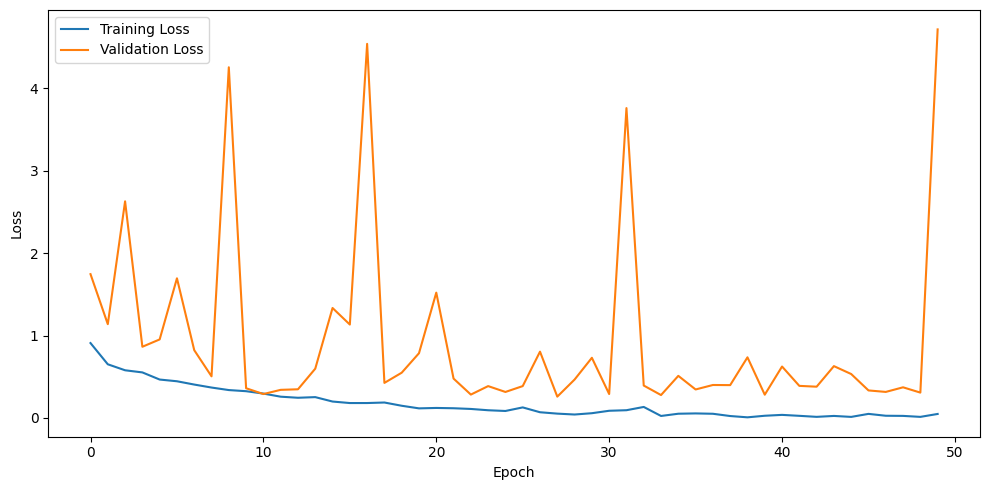

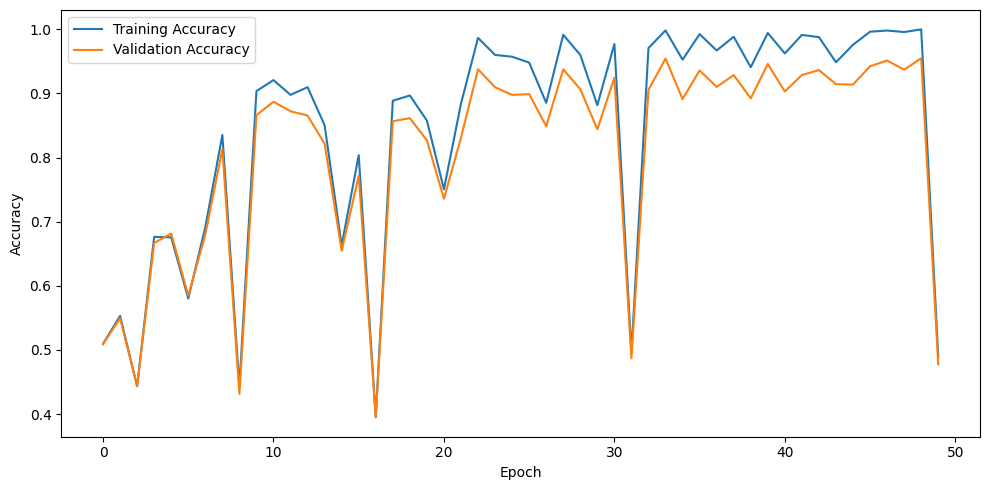

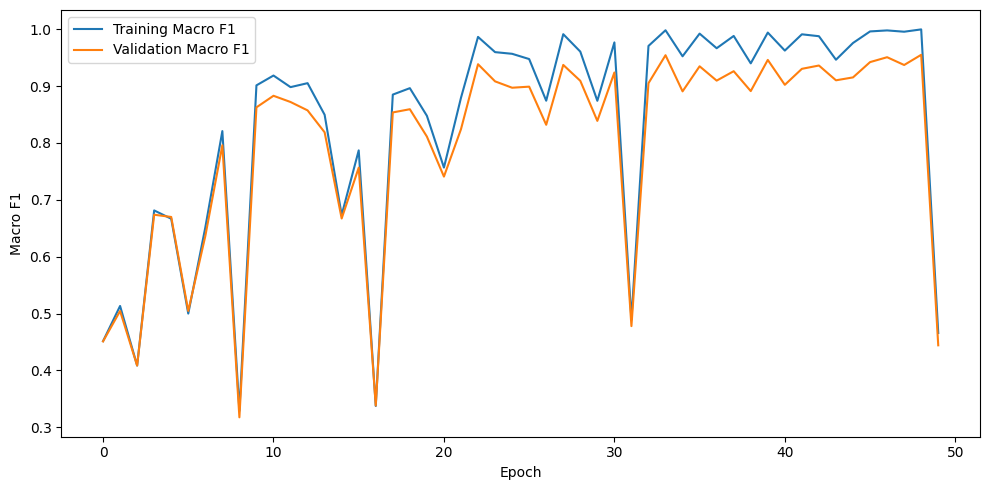

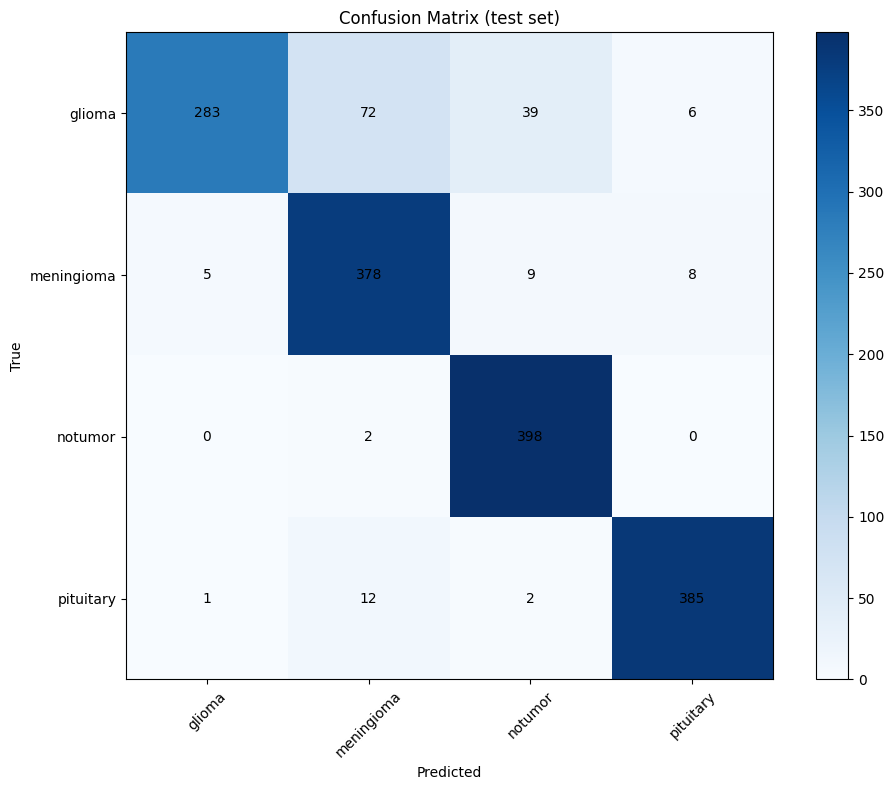

In [17]:
def plot_training_curves(history: Dict[str, List[float]], cm_test: np.ndarray) -> None:
    # Loss per epoch (training batch mean vs validation eval loss)
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_losses"], label="Training Loss")
    plt.plot(history["val_losses"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()

    # Accuracy on train / val after each epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_accuracies"], label="Training Accuracy")
    plt.plot(history["val_accuracies"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()

    # Macro F1 on train / val after each epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_macro_f1s"], label="Training Macro F1")
    plt.plot(history["val_macro_f1s"], label="Validation Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.legend()
    plt.tight_layout()

    # Confusion matrix on held-out test set
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_test, cmap="Blues")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (test set)")
    plt.xticks(range(NUM_CLASSES), CLASSES, rotation=45)
    plt.yticks(range(NUM_CLASSES), CLASSES)
    #add text to the confusion matrix
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, cm_test[i, j], ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    model, device, history, cm_test = main()
    plot_training_curves(history, cm_test)
